In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import SimpleRNN, Dense, Embedding
from keras.models import Sequential
# from tensorflow import keras
# from keras._tf_keras.keras.layers import SimpleRNN, Dense, Embedding

import matplotlib.pyplot as plt

In [2]:
past_days_to_predict_future = 60

In [3]:
path_file = "../data/interim/"
test_path_file = "../data/external/"
train = pd.read_csv(path_file + "nvidia_stock_data_update.csv")
train_part2 = pd.read_csv(test_path_file + "nvidia_stock_data_test.csv")

In [37]:
train.tail(10)

,Unnamed: 0,Date,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Period_NVDA,Shares_Out_NVDA,Market_Cap_NVDA,...,PS_Ratio_NVDA,Total_Debt_NVDA,Cash_Equivalents_NVDA,TD_CE_Missing_NVDA,Shares_Out_Missing_NVDA,PE_Missing_NVDA,PS_Missing_NVDA,EV_NVDA,Daily_Change_%,Unusual_Activity
6576,NaN,2025-03-14,121.67,121.880,118.15,118.610,277593455.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6577,NaN,2025-03-17,119.53,122.890,118.03,122.740,255501481.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6578,NaN,2025-03-18,115.43,119.020,114.54,118.000,299686944.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6579,NaN,2025-03-19,117.52,120.445,115.68,117.270,273426225.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6580,NaN,2025-03-20,118.53,120.200,116.47,116.550,248829749.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6581,NaN,2025-03-21,117.70,117.990,115.42,116.940,266498528.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6582,NaN,2025-03-24,121.41,122.220,119.34,119.880,228452534.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6583,NaN,2025-03-25,120.69,121.290,118.92,120.545,167447198.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6584,NaN,2025-03-26,113.76,118.840,112.71,118.730,296431667.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6585,NaN,2025-03-27,111.43,114.450,110.66,111.350,236902055.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
train.tail()

,Unnamed: 0,Date,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Period_NVDA,Shares_Out_NVDA,Market_Cap_NVDA,...,PS_Ratio_NVDA,Total_Debt_NVDA,Cash_Equivalents_NVDA,TD_CE_Missing_NVDA,Shares_Out_Missing_NVDA,PE_Missing_NVDA,PS_Missing_NVDA,EV_NVDA,Daily_Change_%,Unusual_Activity
6534,6534,2025-01-13,133.217743,133.477729,129.498084,129.978051,204808900,after_trump,2.541310e+10,3.385476e+12,...,25.942939,1.105600e+10,7.280000e+09,0,0,0,0,3.389252e+12,-1.971901,False
6535,6535,2025-01-14,131.747879,136.367465,130.038045,136.037493,195590500,after_trump,2.541310e+10,3.348122e+12,...,25.656696,1.105600e+10,7.280000e+09,0,0,0,0,3.351898e+12,-1.103354,False
6536,6536,2025-01-15,136.227478,136.437450,131.277921,133.637705,185217300,after_trump,2.541310e+10,3.461962e+12,...,26.529057,1.105600e+10,7.280000e+09,0,0,0,0,3.465738e+12,3.400130,False
6537,6537,2025-01-16,133.557724,138.737240,133.477730,138.627250,209235600,after_trump,2.541310e+10,3.394116e+12,...,26.009147,1.105600e+10,7.280000e+09,0,0,0,0,3.397892e+12,-1.959776,False
6538,6538,2025-01-17,137.697342,138.487263,135.447549,136.677431,201188800,after_trump,2.497950e+10,3.439611e+12,...,26.357775,1.105600e+10,7.280000e+09,0,0,0,0,3.443387e+12,3.099497,False


In [ ]:
train_part2.columns = ["Date", "Open_NVDA", "High_NVDA", "Low_NVDA", "Close_NVDA", "Volume_NVDA"]
train_part2.head()

,Date,Open_NVDA,High_NVDA,Low_NVDA,Close_NVDA,Volume_NVDA
0,2025-01-21,139.16,141.83,137.09,140.83,197748985.0
1,2025-01-22,144.66,147.79,143.67,147.07,237651395.0
2,2025-01-23,145.05,147.23,143.72,147.22,155915549.0
3,2025-01-24,148.37,148.97,141.88,142.62,234657635.0
4,2025-01-27,124.80,128.40,116.70,118.42,818830895.0


In [8]:
train_part2.shape

(77, 6)

In [9]:
train = pd.concat([train, train_part2[:47]], ignore_index=True)

In [10]:
train.tail()

,Unnamed: 0,Date,Close_NVDA,High_NVDA,Low_NVDA,Open_NVDA,Volume_NVDA,Period_NVDA,Shares_Out_NVDA,Market_Cap_NVDA,...,PS_Ratio_NVDA,Total_Debt_NVDA,Cash_Equivalents_NVDA,TD_CE_Missing_NVDA,Shares_Out_Missing_NVDA,PE_Missing_NVDA,PS_Missing_NVDA,EV_NVDA,Daily_Change_%,Unusual_Activity
6581,NaN,2025-03-21,117.70,117.99,115.42,116.940,266498528.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6582,NaN,2025-03-24,121.41,122.22,119.34,119.880,228452534.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6583,NaN,2025-03-25,120.69,121.29,118.92,120.545,167447198.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6584,NaN,2025-03-26,113.76,118.84,112.71,118.730,296431667.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6585,NaN,2025-03-27,111.43,114.45,110.66,111.350,236902055.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
test = train_part2.iloc[-30:]

In [12]:
test.head()

,Date,Open_NVDA,High_NVDA,Low_NVDA,Close_NVDA,Volume_NVDA
47,2025-03-28,111.485,112.870,109.0701,109.67,229872549.0
48,2025-03-31,105.130,110.955,103.6500,108.38,299212653.0
49,2025-04-01,108.515,110.200,106.4700,110.15,222614034.0
50,2025-04-02,107.290,111.980,106.7900,110.42,220601243.0
51,2025-04-03,103.510,105.630,101.6000,101.80,338769412.0


In [13]:
train.shape

(6586, 23)

In [14]:
test.shape

(30, 6)

In [15]:
# making the training data only the values from the Open column.
training_set = train.iloc[:, 5:6].values
training_set

array([[4.01187826e-02],
       [4.05965509e-02],
       [4.20289016e-02],
       ...,
       [1.20545000e+02],
       [1.18730000e+02],
       [1.11350000e+02]])

In [16]:
training_set[0]

array([0.04011878])

In [17]:
# standardizing
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [18]:
training_set_scaled

array([[5.30717312e-05],
       [5.61947282e-05],
       [6.55574816e-05],
       ...,
       [7.87749462e-01],
       [7.75885470e-01],
       [7.27645106e-01]])

In [19]:
# play 60 values into one row to train the past 60 days for the following 60 days
X_train = []
y_train = []
for i in range(past_days_to_predict_future, len(train)):
    X_train.append(training_set_scaled[i-past_days_to_predict_future:i, 0]) # Select the timesteps of range i and select from the first column
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

In [20]:
X_train.shape

(6526, 60)

In [21]:
y_train.shape

(6526,)

In [22]:
print(len(X_train[3]))

60


In [23]:
X_train.shape

(6526, 60)

In [24]:
# need to reshape so that the input layer is proper for the RNN
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

(6526, 60, 1)

In [25]:
model = Sequential()
model.add(SimpleRNN(past_days_to_predict_future,input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(SimpleRNN(past_days_to_predict_future))
model.add(Dense(1))

model.compile(optimizer = 'adam', loss = 'mean_squared_error')

model.fit(X_train, y_train, epochs = 30, batch_size = 64)

Epoch 1/30


/opt/anaconda3/envs/DeepLearning/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0145
Epoch 2/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.5937e-04
Epoch 3/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.1854e-04
Epoch 4/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.2724e-04
Epoch 5/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0356e-04
Epoch 6/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.9268e-05
Epoch 7/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.3457e-05
Epoch 8/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.3928e-05
Epoch 9/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.6397e-04
Epoch 10/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4008e-05
Epoch 11/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.8267e-05
Epoch 12/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.5556e-05
Epoch 13/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.2438e-05
Epoch 14/30
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.7476e-05
Epoch 15/30
102/

In [26]:
real_stock_price = test.iloc[:, 1:2].values
# Getting the predicted stock price
dataset_total = pd.concat((train["Open_NVDA"], test["Open_NVDA"]), axis = 0)
inputs = dataset_total[len(dataset_total) - len(test) - past_days_to_predict_future:].values

In [27]:
inputs.shape

(90,)

In [28]:
inputs = inputs.reshape(-1,1)
inputs.shape

(90, 1)

In [29]:
inputs = sc.transform(inputs)

In [30]:
len(test)

30

In [31]:
X_test = []

# Creating timestamps
for i in range(past_days_to_predict_future, len(test)+past_days_to_predict_future):
    X_test.append(inputs[i-past_days_to_predict_future:i, 0])

X_test = np.array(X_test)

# Transforming 3D Features
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Final Predictions
predicted_stock_price = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step


In [32]:
predicted_stock_price.shape

(30, 1)

In [33]:
# RESHAPE
predicted_stock_price = predicted_stock_price.reshape((predicted_stock_price.shape[0], -1))
predicted_stock_price.shape

(30, 1)

In [34]:
predicted_stock_price = sc.inverse_transform(predicted_stock_price)
predicted_stock_price

array([[118.96654 ],
       [117.604256],
       [110.808136],
       [113.15072 ],
       [112.9167  ],
       [107.64132 ],
       [104.73849 ],
       [ 92.31708 ],
       [108.49937 ],
       [104.8732  ],
       [114.11378 ],
       [113.92037 ],
       [118.90738 ],
       [116.72565 ],
       [111.71245 ],
       [110.738174],
       [106.884964],
       [105.91159 ],
       [109.434654],
       [110.56467 ],
       [112.108406],
       [114.766335],
       [112.98137 ],
       [111.17077 ],
       [117.088745],
       [118.86616 ],
       [117.71957 ],
       [116.24408 ],
       [118.109024],
       [123.89014 ]], dtype=float32)

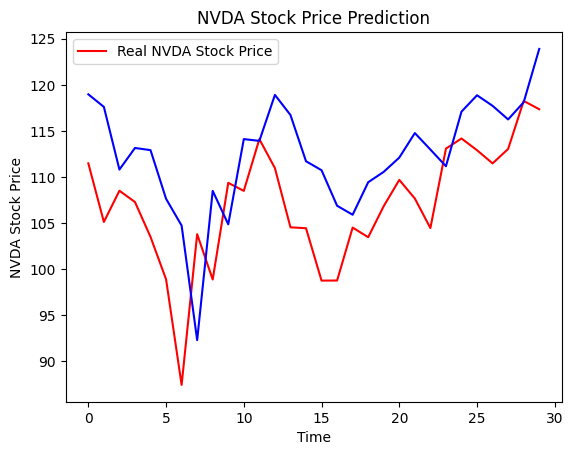

In [35]:
# Visualising the results
plt.plot(real_stock_price, color = 'red', label = 'Real NVDA Stock Price')
plt.plot(predicted_stock_price, color = 'blue')
plt.title('NVDA Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('NVDA Stock Price')
plt.legend()
plt.show()